In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('../data/processed', exist_ok=True)

# --- logon.csv ---
logon = pd.read_csv("../data/raw/r4.2/logon.csv")
print("logon shape:", logon.shape)
print("columns:", logon.columns.tolist())
print(logon.head(3))
print("activity values:", logon['activity'].unique())
print("unique users:", logon['user'].nunique())

logon shape: (854859, 5)
columns: ['id', 'date', 'user', 'pc', 'activity']
                         id                 date     user       pc activity
0  {X1D9-S0ES98JV-5357PWMI}  01/02/2010 06:49:00  NGF0157  PC-6056    Logon
1  {G2B3-L6EJ61GT-2222RKSO}  01/02/2010 06:50:00  LRR0148  PC-4275    Logon
2  {U6Q3-U0WE70UA-3770UREL}  01/02/2010 06:53:04  LRR0148  PC-4124    Logon
activity values: <StringArray>
['Logon', 'Logoff']
Length: 2, dtype: str
unique users: 1000


In [4]:
# --- device.csv ---
device = pd.read_csv("../data/raw/r4.2/device.csv")
print("device shape:", device.shape)
print("activity values:", device['activity'].unique())

device shape: (405380, 5)
activity values: <StringArray>
['Connect', 'Disconnect']
Length: 2, dtype: str


In [ ]:
# --- file.csv ---
file_df = pd.read_csv("../data/raw/r4.2/file.csv")
print("file shape:", file_df.shape)
print("file columns:", file_df.columns.tolist())
print(file_df.head(3))

file shape: (445581, 6)
file columns: ['id', 'date', 'user', 'pc', 'filename', 'content']
                         id                 date     user       pc  \
0  {L9G8-J9QE34VM-2834VDPB}  01/02/2010 07:23:14  MOH0273  PC-6699   
1  {H0W6-L4FG38XG-9897XTEN}  01/02/2010 07:26:19  MOH0273  PC-6699   
2  {M3Z0-O2KK89OX-5716MBIM}  01/02/2010 08:12:03  HPH0075  PC-2417   

       filename                                            content  
0  EYPC9Y08.doc  D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...  
1  N3LTSU3O.pdf  25-50-44-46-2D carpenters 25 landed strait dis...  
2  D3D3WC9W.doc  D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...  


In [6]:
# --- email.csv (read only first 5 rows to check columns — it is very large) ---
email = pd.read_csv("../data/raw/r4.2/email.csv", nrows=5)
print("email columns:", email.columns.tolist())
print(email.head(3))

email columns: ['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']
                         id                 date     user       pc  \
0  {R3I7-S4TX96FG-8219JWFF}  01/02/2010 07:11:45  LAP0338  PC-5758   
1  {R0R9-E4GL59IK-2907OSWJ}  01/02/2010 07:12:16  MOH0273  PC-6699   
2  {G2B2-A8XY58CP-2847ZJZL}  01/02/2010 07:13:00  LAP0338  PC-5758   

                                                  to  \
0  Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...   
1                        Odonnell-Gage@bellsouth.net   
2                         Penelope_Colon@netzero.com   

                                cc  bcc                        from   size  \
0  Nathaniel.Hunter.Heath@dtaa.com  NaN   Lynn.Adena.Pratt@dtaa.com  25830   
1                              NaN  NaN         MOH68@optonline.net  29942   
2                              NaN  NaN  Lynn_A_Pratt@earthlink.net  28780   

   attachments                                            content  
0       

In [7]:
# --- http.csv (read only first 5 rows — it is HUGE) ---
http = pd.read_csv("../data/raw/r4.2/http.csv", nrows=5)
print("http columns:", http.columns.tolist())
print(http.head(3))


http columns: ['id', 'date', 'user', 'pc', 'url', 'content']
                         id                 date     user       pc  \
0  {V1Y4-S2IR20QU-6154HFXJ}  01/02/2010 06:55:16  LRR0148  PC-4275   
1  {Q5R1-T3EF87UE-2395RWZS}  01/02/2010 07:00:13  NGF0157  PC-6056   
2  {X9O1-O0XW52VO-5806RPHG}  01/02/2010 07:03:46  NGF0157  PC-6056   

                                                 url  \
0  http://msn.com/The_Human_Centipede_First_Seque...   
1  http://urbanspoon.com/Plunketts_Creek_Loyalsoc...   
2  http://aa.com/Rhodocene/rhodocenium/fhaavatqrf...   

                                             content  
0  remain representatives consensus concert altho...  
1  festival off northwards than congestion partne...  
2  long away reorganized baldwin seth business 18...  


psychometric shape: (1000, 7)
             employee_name  user_id   O   C   E   A   N
0         Calvin Edan Love  CEL0561  40  39  36  19  40
1  Christine Reagan Deleon  CRD0624  26  22  17  39  32
2    Jade Felicia Caldwell  JFC0557  22  16  23  40  33
3   Aquila Stewart Dejesus  ASD0577  40  48  36  14  37
4        Micah Abdul Rojas  MAR0955  36  44  23  44  25


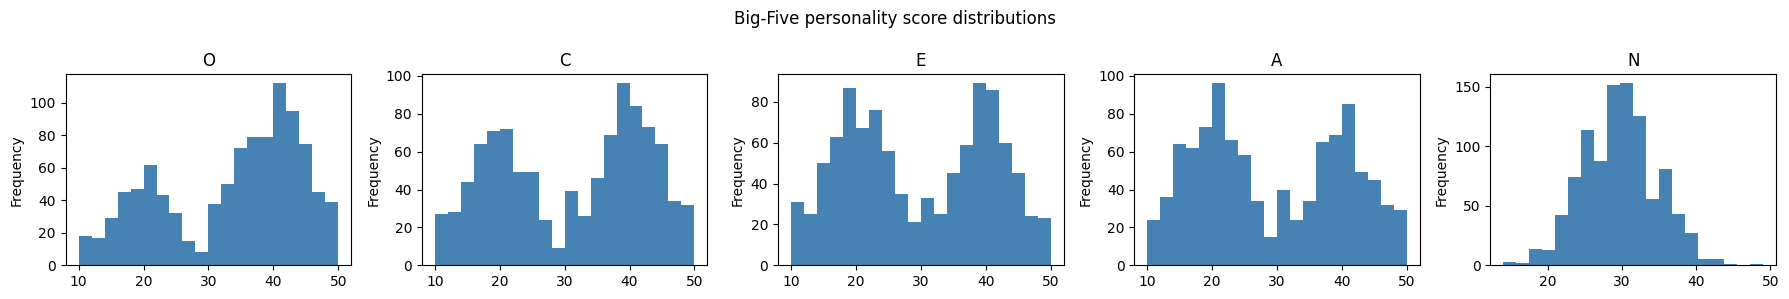

In [9]:
# --- psychometric.csv ---
psych = pd.read_csv("../data/raw/r4.2/psychometric.csv")
print("psychometric shape:", psych.shape)
print(psych.head(5))

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, col in zip(axes, ['O','C','E','A','N']):
    psych[col].plot(kind='hist', ax=ax, bins=20, title=col, color='steelblue')
plt.suptitle('Big-Five personality score distributions')
plt.tight_layout()
plt.savefig('../data/processed/psychometric_distributions.png')
plt.show()

In [13]:
# --- answers/insiders.csv ---
insiders = pd.read_csv("../data/raw/answers/insiders.csv")
print("insiders shape:", insiders.shape)
print("columns:", insiders.columns.tolist())
print(insiders.head(10))

# How many unique malicious users?
r42_insiders = insiders[insiders['dataset'].astype(str).str.contains('4.2', na=False)]
print(f"\nMalicious users in r4.2: {r42_insiders['user'].nunique()}")
print(r42_insiders[['user','scenario','start','end']].to_string())
print("\nScenarios found:")
print(r42_insiders['scenario'].value_counts())
print("\nInsider user IDs (save these — needed for evaluation):")
insider_ids = r42_insiders['user'].str.upper().unique().tolist()
print(insider_ids)

insiders shape: (191, 6)
columns: ['dataset', 'scenario', 'details', 'user', 'start', 'end']
   dataset  scenario             details     user                start  \
0      2.0         1              r2.csv  ONS0995     3/6/2010 1:41:56   
1      3.1         1          r3.1-1.csv  CSF0929  07/01/2010 01:24:58   
2      3.1         2          r3.1-2.csv  CCH0959  08/02/2010 10:34:31   
3      3.2         1          r3.2-1.csv  RCW0822  09/29/2010 21:10:27   
4      3.2         2          r3.2-2.csv  JCE0258  07/12/2010 08:16:02   
5      4.1         1          r4.1-1.csv  ABB0427  08/21/2010 05:20:34   
6      4.1         2          r4.1-2.csv  HFC0492  08/23/2010 10:40:56   
7      4.1         3          r4.1-3.csv  KTW0365  07/08/2010 11:51:00   
8      4.2         1  r4.2-1-AAM0658.csv  AAM0658  10/23/2010 01:34:19   
9      4.2         1  r4.2-1-AJR0932.csv  AJR0932  09/10/2010 19:12:01   

                   end  
0    3/20/2010 8:10:12  
1  07/16/2010 06:52:00  
2  09/30/2010 15:

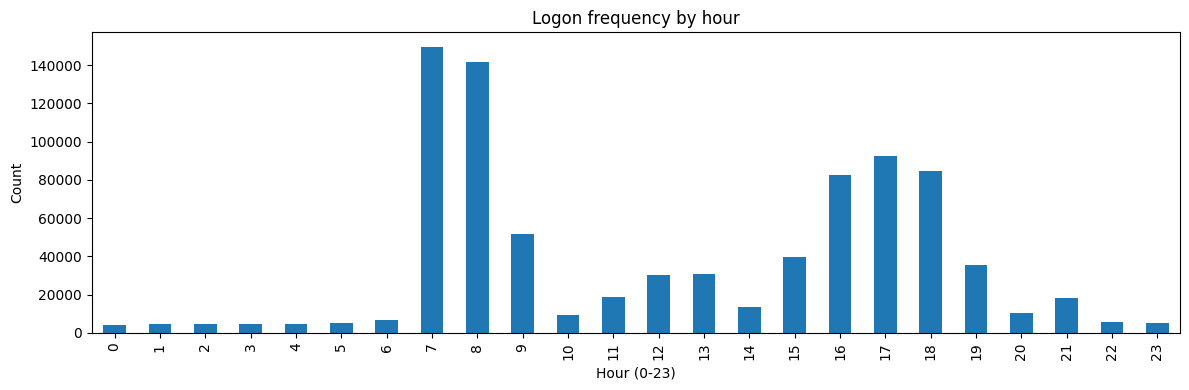

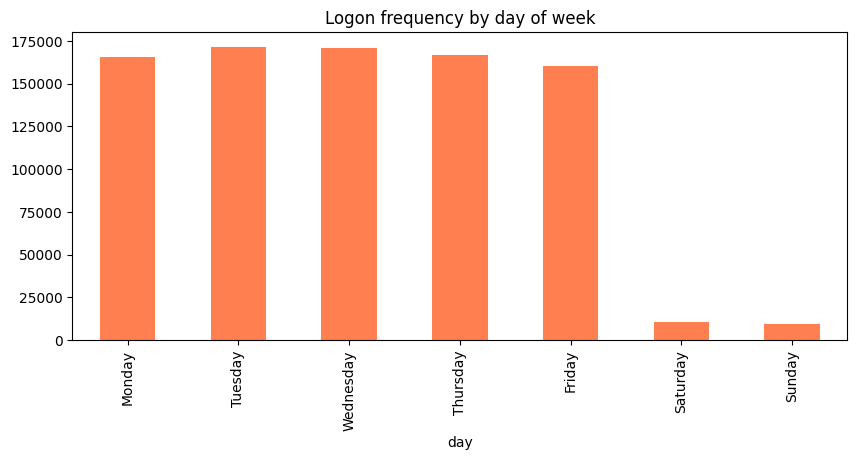

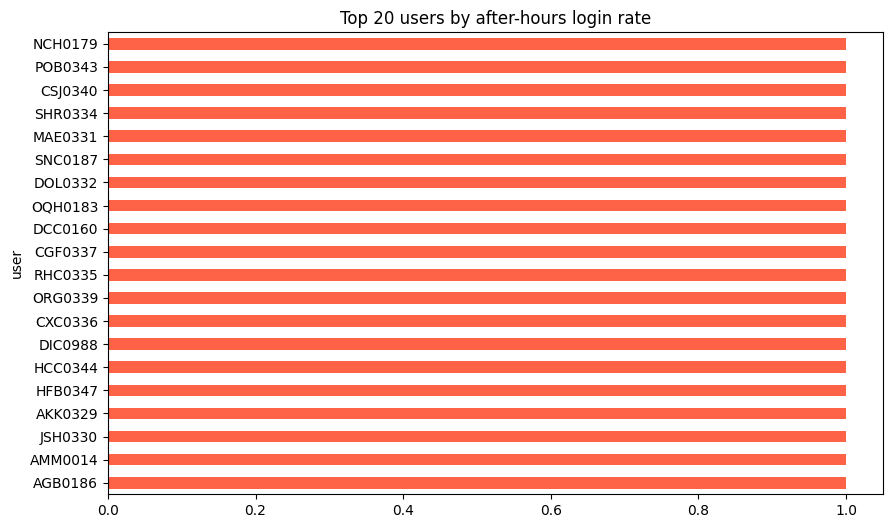

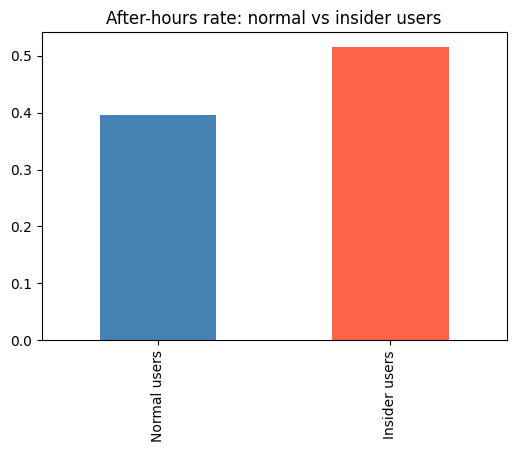

In [14]:
# --- Time distribution of logons ---
logon['date'] = pd.to_datetime(logon['date'])
logon['hour'] = logon['date'].dt.hour
logon['hour'].value_counts().sort_index().plot(kind='bar', figsize=(12,4))
plt.title("Logon frequency by hour")
plt.xlabel("Hour (0-23)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../data/processed/logon_hours.png")
plt.show()
# Chart 2 — ADD: logons by day of week
logon['day'] = logon['date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
logon['day'].value_counts()[day_order].plot(kind='bar', figsize=(10,4), color='coral')
plt.title('Logon frequency by day of week'); plt.savefig('../data/processed/logon_days.png'); plt.show()
# Chart 3 — ADD: after-hours rate per user (top 20 most suspicious)
logon['is_after_hours'] = (logon['hour'] < 8) | (logon['hour'] >= 18)
after_hrs = logon.groupby('user')['is_after_hours'].mean().sort_values(ascending=False).head(20)
after_hrs.plot(kind='barh', figsize=(10,6), color='tomato')
plt.title('Top 20 users by after-hours login rate')
plt.savefig('../data/processed/after_hours_users.png'); plt.show()
# Chart 4 — ADD: highlight insider users vs normal users
logon['is_insider'] = logon['user'].str.upper().isin(insider_ids)
comp = logon.groupby('is_insider')['is_after_hours'].mean()
comp.index = ['Normal users','Insider users']
comp.plot(kind='bar', figsize=(6,4), color=['steelblue','tomato'])
plt.title('After-hours rate: normal vs insider users')
plt.savefig('../data/processed/insider_vs_normal.png'); plt.show()

In [15]:
print("=" * 50)
print(" DATASET SUMMARY — CERT r4.2")
print("=" * 50)
print(f"Total logon events : {len(logon):,}")
print(f"Unique users : {logon['user'].nunique():,}")
print(f"Date range : {logon['date'].min()} → {logon['date'].max()}")
print(f"Total device events : {len(device):,}")
print(f"Psychometric users : {len(psych):,}")
print(f"Insider users (r4.2) : {len(insider_ids)}")
print(f"Insider IDs : {insider_ids}")
print(f"Scenarios : {r42_insiders['scenario'].unique().tolist()}")
print("=" * 50)

 DATASET SUMMARY — CERT r4.2
Total logon events : 854,859
Unique users : 1,000
Date range : 2010-01-02 06:49:00 → 2011-05-17 06:43:35
Total device events : 405,380
Psychometric users : 1,000
Insider users (r4.2) : 70
Insider IDs : ['AAM0658', 'AJR0932', 'BDV0168', 'BIH0745', 'BLS0678', 'BTL0226', 'CAH0936', 'DCH0843', 'EHB0824', 'EHD0584', 'FMG0527', 'FTM0406', 'GHL0460', 'HJB0742', 'JMB0308', 'JRG0207', 'KLH0596', 'KPC0073', 'LJR0523', 'LQC0479', 'MAR0955', 'MAS0025', 'MCF0600', 'MYD0978', 'PPF0435', 'RAB0589', 'RGG0064', 'RKD0604', 'TAP0551', 'WDD0366', 'AAF0535', 'ABC0174', 'AKR0057', 'CCL0068', 'CEJ0109', 'CQW0652', 'DIB0285', 'DRR0162', 'EDB0714', 'EGD0132', 'FSC0601', 'HBO0413', 'HXL0968', 'IJM0776', 'IKR0401', 'IUB0565', 'JJM0203', 'KRL0501', 'LCC0819', 'MDH0580', 'MOS0047', 'NWT0098', 'PNL0301', 'PSF0133', 'RAR0725', 'RHL0992', 'RMW0542', 'TNM0961', 'VSS0154', 'XHW0498', 'BBS0039', 'BSS0369', 'CCA0046', 'CSC0217', 'GTD0219', 'JGT0221', 'JLM0364', 'JTM0223', 'MPM0220', 'MSO0222'